In [1]:
# import libraries

import numpy as np
import pandas as pd
import geopandas as gpd

import matplotlib.pyplot as plt

import os

Import files

In [2]:
travel_mode_input_folder = "Aggregated Data"
travel_mode_pct_df = pd.read_csv(os.path.join(travel_mode_input_folder,"district_travel_mode_pct.csv"))

Plot the % change in Travel Modes

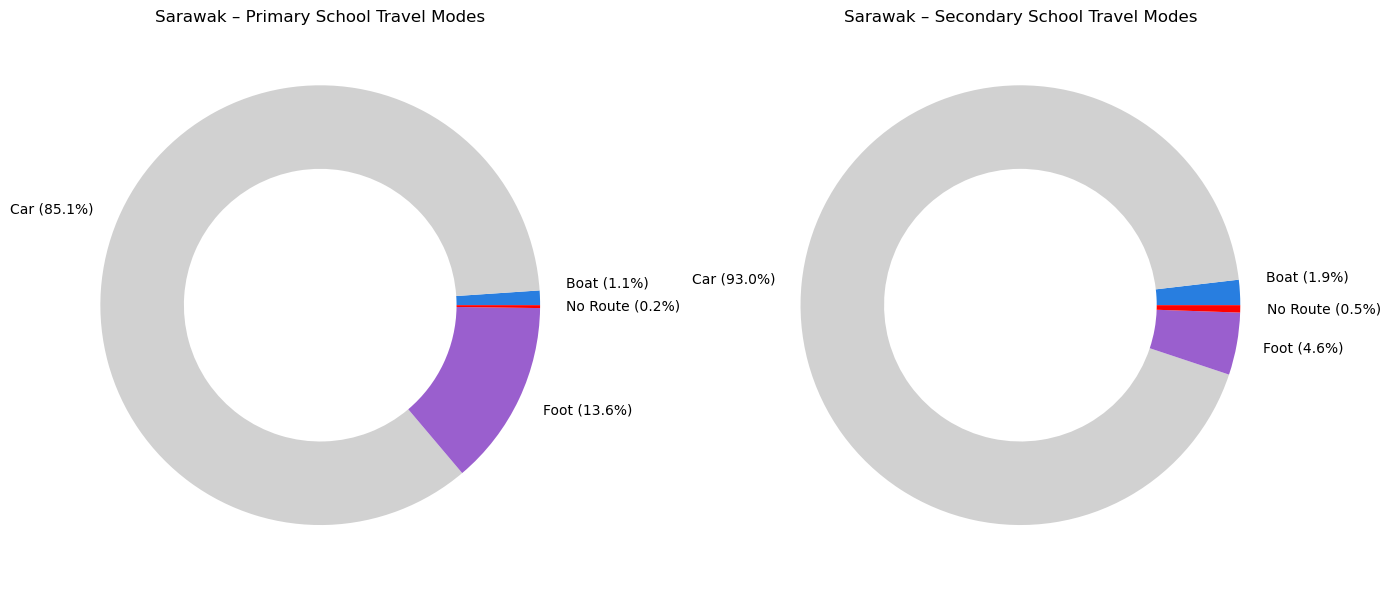

In [3]:
# Read df
df = travel_mode_pct_df

# Extract Sarawak row
swk = df[df["district"] == "Sarawak"].iloc[0]

# Collect all primary/secondary mode percentages
primary_modes = {
    "Boat": swk["boat_primary_pct"],
    "Car": swk["car_primary_pct"],
    "Foot": swk["foot_primary_pct"],
    "No Route": swk["no_route_primary_pct"],
}

secondary_modes = {
    "Boat": swk["boat_secondary_pct"],
    "Car": swk["car_secondary_pct"],
    "Foot": swk["foot_secondary_pct"],
    "No Route": swk["no_route_secondary_pct"],
}

# Flatter colour
colour_map = {
    "Boat": "#287ee0",      # flat blue
    "Car": "#d1d1d1",       # flat grey
    "Foot": "#9a5fce",      # flat purple
    "No Route": "#ff0000",  # flat red
}

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# --- Helper function to push up the "Boat" text ---
def lift_boat_label(axis, lift=0.06):
    for t in axis.texts:
        if "Boat" in t.get_text():
            x, y = t.get_position()
            t.set_position((x, y + lift))   # move label upward


# -------------------------
# Primary donut
# -------------------------
ax[0].pie(
    primary_modes.values(),
    labels=[f"{k} ({v:.1f}%)" for k, v in primary_modes.items()],
    colors=[colour_map[k] for k in primary_modes.keys()],
    wedgeprops={'width': 0.38},
    labeldistance=1.12,
    pctdistance=0.5,
    textprops={'fontsize': 10}
)
lift_boat_label(ax[0], lift=0.06)  # <<< push up Boat
ax[0].set_title("Sarawak – Primary School Travel Modes")


# -------------------------
# Secondary donut
# -------------------------
ax[1].pie(
    secondary_modes.values(),
    labels=[f"{k} ({v:.1f}%)" for k, v in secondary_modes.items()],
    colors=[colour_map[k] for k in secondary_modes.keys()],
    wedgeprops={'width': 0.38},
    labeldistance=1.12,
    pctdistance=0.5,
    textprops={'fontsize': 10}
)
lift_boat_label(ax[1], lift=0.06)  # <<< push up Boat
ax[1].set_title("Sarawak – Secondary School Travel Modes")


plt.tight_layout()
plt.show()
